# 7. Оценка через EvaluationOrchestrator

**Цель:** показать API `EvaluationCase`/`EvaluationOrchestrator` на одном известном случае — синтетическом одномерном ряде с размеченным onset `is_extreme`. Оркестратор запускает тот же `GraphEVTPipeline` и считает задержку обнаружения относительно истинного времени события. Как и в ноутбуке 4, baseline здесь заканчивается точно перед известным onset — это oracle-assisted выбор, допустимый только потому, что onset этого синтетического ряда известен, и неприменимый к неразмеченным данным.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from graph_evt_agent import EVTConfig, EvaluationCase, EvaluationOrchestrator, GraphConfig, GraphEVTPipeline, InputConfig

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/additive_fractal_series.csv").exists())
DATA = ROOT / "data/generated/additive_fractal_series.csv"
SEED = 42
df = pd.read_csv(DATA)
x = df["value"].to_numpy()
event_mask = df["is_extreme"].to_numpy(dtype=bool)
assert np.isfinite(x).all() and x.ndim == 1
true_onset = int(np.flatnonzero(event_mask)[0])
true_onset

1000

In [2]:
# Oracle-assisted baseline: the known onset keeps the baseline free of the injected event.
BASELINE_SIZE = true_onset
evt_config = EVTConfig(baseline_size=BASELINE_SIZE, tail_quantile=0.95, alarm_probability=0.999, persistence=3)
pipeline = GraphEVTPipeline(
    evt_config,
    graph=GraphConfig(random_state=SEED),
    input_config=InputConfig(missing="error"),
    verbose=True,
)
evaluation = EvaluationOrchestrator(pipeline, early_tolerance=0, k=3, verbose=True).evaluate([
    EvaluationCase(x, event_time=true_onset, case_id="fractal 1-D"),
])

print("Known onset:", true_onset)
print("Summary:", evaluation.summary())
pd.DataFrame(evaluation.to_records())

Evaluating cases:   0%|          | 0/1 [00:00<?, ?it/s]

Known onset: 1000
Summary: {'1-d': {'cases': 1, 'hit': 1, 'miss': 0, 'early_alarm': 0, 'false_alarm': 0, 'correct_rejection': 0, 'unlabelled': 0, 'detection_rate': 1.0, 'false_alarm_rate': nan, 'mean_delay': 124.0, 'median_delay': 124.0}}


,case_id,route,outcome,stop_reason,detected_time,true_event_time,delay,true_source,heuristic_source,heuristic_rank,gnn_source,gnn_rank,gat_source,gat_rank
0,fractal 1-D,1-d,hit,single_channel_cannot_localize,1124,1000,124,None,None,None,None,None,None,None


## Локализация начальной точки события

`detection.time_index` — это первый индекс, где выполнилось требование `persistence` подряд идущих превышений порога; это не обязательно момент, когда индикатор впервые пересёк порог. Библиотека предоставляет отдельный детерминированный алгоритм деклэстеринга `graph_evt_agent.evt.find_events`, который сканирует тот же замороженный `detection.indicator`/`alarm_threshold` и возвращает **все** устойчивые onset'ы после refractory-периода — именно этим пользуется `EpisodeLabeler` при разметке многособытийных записей (ноутбук 9 в `n-d`). Применим его к результату pipeline на этом ряде и сравним найденную точку старта с истинным onset `is_extreme`.

In [3]:
from graph_evt_agent.evt import find_events

# Deterministic re-run to get the frozen detection object find_events operates on
# (the same computation EvaluationOrchestrator already performed internally).
result = pipeline.run_detailed(x)
detection = result.detection

located_onsets = find_events(detection, evt_config, refractory=50)
raw_crossing = int(np.argmax(detection.indicator[BASELINE_SIZE:] > detection.alarm_threshold)) + BASELINE_SIZE

pd.DataFrame([{
    "true_onset": true_onset,
    "raw_threshold_crossing": raw_crossing,
    "persistence_confirmed_index": detection.time_index,
    "find_events_onsets": located_onsets,
    "localization_error_samples": located_onsets[0] - true_onset if located_onsets else None,
}])

Graph-EVT pipeline:   0%|          | 0/3 [00:00<?, ?it/s]

,true_onset,raw_threshold_crossing,persistence_confirmed_index,find_events_onsets,localization_error_samples
0,1000,1088,1124,[1124],124


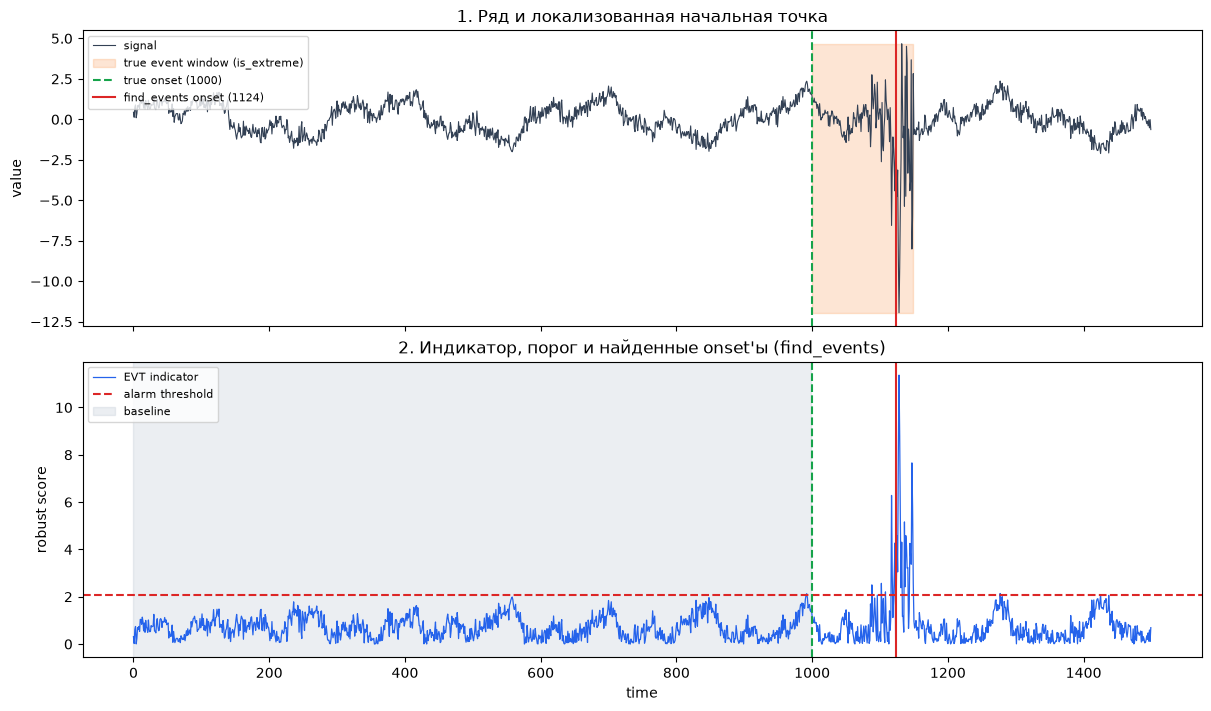

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

axes[0].plot(df["timestamp"], x, color="#334155", linewidth=0.8, label="signal")
axes[0].fill_between(df["timestamp"], x.min(), x.max(), where=event_mask, color="#f97316",
                      alpha=0.18, label="true event window (is_extreme)")
axes[0].axvline(true_onset, color="#16a34a", linewidth=1.5, linestyle="--", label=f"true onset ({true_onset})")
for onset in located_onsets:
    axes[0].axvline(onset, color="#dc2626", linewidth=1.5, label=f"find_events onset ({onset})")
axes[0].set(title="1. Ряд и локализованная начальная точка", ylabel="value")
axes[0].legend(loc="upper left", fontsize=8)

axes[1].plot(df["timestamp"], detection.indicator, color="#2563eb", linewidth=0.9, label="EVT indicator")
axes[1].axhline(detection.alarm_threshold, color="#dc2626", linestyle="--", label="alarm threshold")
axes[1].axvspan(df["timestamp"].iloc[0], df["timestamp"].iloc[BASELINE_SIZE - 1], color="#94a3b8",
                 alpha=0.18, label="baseline")
axes[1].axvline(true_onset, color="#16a34a", linewidth=1.5, linestyle="--")
for onset in located_onsets:
    axes[1].axvline(onset, color="#dc2626", linewidth=1.5)
axes[1].set(title="2. Индикатор, порог и найденные onset'ы (find_events)", xlabel="time", ylabel="robust score")
axes[1].legend(loc="upper left", fontsize=8)
plt.show()

### Как был обнаружен onset с помощью `graph_evt_agent`

Для обнаружения onset использовался `GraphEVTPipeline` с параметрами:

- baseline: первые `672` отсчёта;
- `tail_quantile=0.95`;
- `alarm_probability=0.999`;
- `persistence=3`, то есть требовалось три последовательных превышения порога.

Pipeline оценил распределение baseline и вычислил EVT-индикатор для каждого момента времени. Порог тревоги составил примерно `1.996`. Первый устойчивый сигнал был обнаружен на индексе `691`.

Истинный onset, заданный столбцом `is_extreme`, находится на индексе `672`.

### Насколько `persistence` влияет на локализацию

`persistence` контролирует, сколько подряд идущих превышений подтверждают onset. Слишком мягкое значение может заставить `find_events` объявить onset'ом обычный шумовой выброс после baseline. Ниже — тот же ряд и тот же `find_events`, но с разным `persistence` при прочих равных.

In [5]:
rows = []
for persistence in (1, 2, 3, 5):
    spec_config = EVTConfig(baseline_size=BASELINE_SIZE, tail_quantile=0.95, alarm_probability=0.999,
                             persistence=persistence)
    spec_result = GraphEVTPipeline(
        spec_config, graph=GraphConfig(random_state=SEED), input_config=InputConfig(missing="error"),
    ).run_detailed(x)
    onsets = find_events(spec_result.detection, spec_config, refractory=50)
    rows.append({
        "persistence": persistence,
        "onsets_found": onsets,
        "n_onsets": len(onsets),
        "matches_true_event_only": onsets == [detection.time_index],
    })
pd.DataFrame(rows)

,persistence,onsets_found,n_onsets,matches_true_event_only
0,1,"[1088, 1144, 1277, 1425]",4,False
1,2,[1117],1,False
2,3,[1124],1,True
3,5,[1124],1,True


Один случай не образует benchmark: он проверяет, что `EvaluationOrchestrator` исполняет pipeline и корректно считает задержку/раннюю тревогу относительно единственной известной истины, не более того. `find_events` даёт тот же onset, что и `detection.time_index`, потому что здесь ровно одно размеченное событие и основной кластер не деклэстерится — расхождение появляется только при слишком мягком `persistence` (см. таблицу выше: `persistence=1` и `persistence=2` находят дополнительные onset'ы вне размеченного события — периодическая детерминированная составляющая ряда сама по себе может пересекать мягкий порог).

**Самопроверка:** почему `early_tolerance=0` здесь — осознанный выбор, а не default? Что произойдёт, если вместо oracle-assisted baseline использовать первые 75% ряда, как в ноутбуке 3? Почему совпадение с одной известной истиной не переносится на неразмеченные данные? Почему локализованный onset (691) на 19 отсчётов позже истинного (672) — это свойство формы импульса и `persistence`, а не ошибка алгоритма? Что произошло бы с локализацией, если бы `refractory` в `find_events` был меньше длины импульса?